In [15]:
import numpy as np
import gymnasium as gym
import importlib
import envs

import learners
import analysis
importlib.reload(analysis)
importlib.reload(learners)
from learners import *
from analysis import *

def get_exp_scheduler(alpha, n_ep_decay, min_val=0.005): return lambda t: max(alpha * 0.5**(t/n_ep_decay), min_val)

params = Params(
    model_name="CliffWindy",
    n_runs=5,
    n_episodes=15_000,
    save_skip=50,
    lr_decay=None,
    seed=123,
    
    N=64,
    alpha=0.6,
    gamma=0.99,
    epsilon=0.0,
    kappa=0.0,
    
    nA=None,
    nS=None,
    shape=None,
)
rng = np.random.default_rng(params.seed)
tau = (np.arange(params.N) + 0.5) / params.N
env = gym.make(params.model_name)
params = params._replace(nA=int(env.action_space.n))
params = params._replace(nS=int(env.observation_space.n))
params = params._replace(shape=env.unwrapped.shape)
s_init, _ = env.reset()

save_to = "results/results/"+params.model_name

In [19]:
policy, V_pi = PolicyIteration(env, params.gamma)
explorer = EpsilonGreedy(rng)

returns = MonteCarlo(env, policy, params.gamma, total_episodes=50_000)
tau_returns = np.quantile(np.sort(returns), tau)

100%|██████████| 50000/50000 [00:08<00:00, 5910.45it/s]


In [17]:
scheduler = get_exp_scheduler(params.alpha, 1250, min_val=0.00025)

table0 = QR(params, policy).train(env, explorer, scheduler)
table1 = QR(params._replace(epsilon=0.1), policy).train(env, explorer, scheduler)
# table1 = QR(1, params, policy).train(env, explorer, scheduler)
# qtable = Qlearner(params, policy).train(env, explorer, scheduler)

100%|██████████| 75000/75000 [02:56<00:00, 424.44it/s, run=5, t=15000]


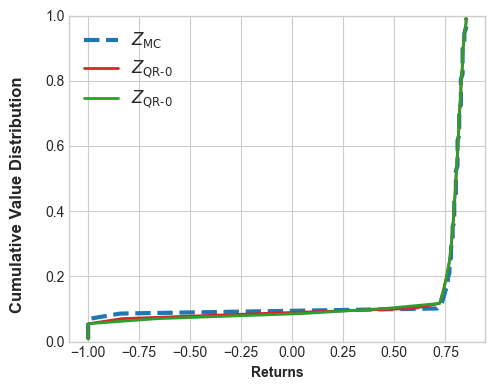

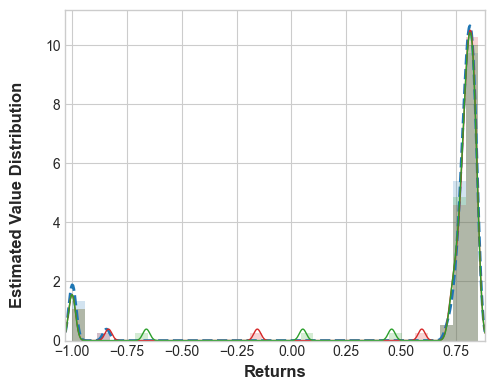

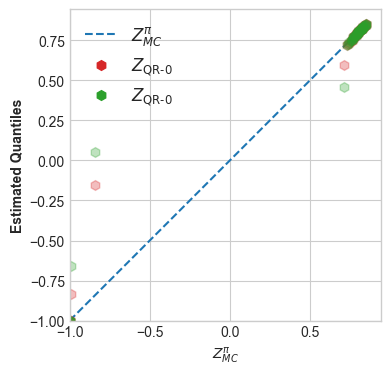

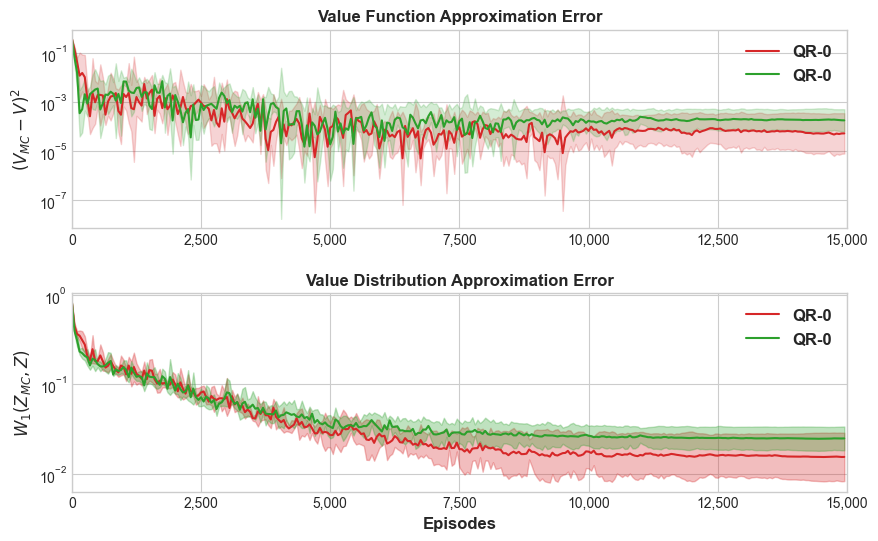

In [20]:
# def get_q(table): return table[:,:,s_init].max(2)
def get_q(table): return table[:,:,s_init, policy[s_init].argmax()]
def get_best(table): return get_q(table)[:,-1].mean(0)

import analysis
importlib.reload(analysis)
from analysis import *

plot_objs = [
    (get_best(table0), r"$Z_{\text{QR-0}}$"),
    (get_best(table1), r"$Z_{\text{QR-0}}$"),
    # (get_best(table1), r"$Z_{\text{QR-1}}$"),
]
plot_qs = [
    (get_q(table0), "QR-0"),
    (get_q(table1), "QR-0"),
    # (get_q(table1), "QR-1"),
    # (get_q(qtable), "Q-learning"),
]

LOW_BANDWIDTH = 0.004
bw = LOW_BANDWIDTH*4.0
plot_cdf(plot_objs, tau_returns, tau, linewidths=(3,2), save_to=save_to, returns_name=r"$Z_{\text{MC}}$")

plot_pdf(plot_objs, tau_returns, bandwidth=bw, show_hist=True, linewidth=1.0, N=params.N//2, hist_alpha=0.2, save_to=save_to)
plot_qq(plot_objs, tau_returns, save_to=save_to, alpha=0.3, markersize=7, lims=(-1,None))
plot_metrics(plot_qs, tau_returns, save_skip=params.save_skip, save_to=save_to, alphas=[0.2,0.3], true_dist="{MC}")